In [ ]:
!pip3 install ucimlrepo

# Breast Cancer Diagnostic Analysis
This project focuses on the Breast Cancer Wisconsin (Diagnostic) dataset. The goal is to build a classification model that can predict whether a tumor is Malignant (M) or Benign (B) based on features computed from a digitized image of a fine needle aspirate (FNA) of a breast mass.

We start by loading the dataset locally. Since the raw .data file doesn't have headers, we're manually defining the feature names based on the dataset documentation (wdbc.names).

Analysis: 

we manually defined the 30 feature names because the raw wdbc.data file is headerless. We dropped the id column immediately since it’s just a patient identifier and would cause the model to overfit on noise. The target variable is 'Diagnosis', which we'll need to encode later for the model.

In [3]:
import pandas as pd

#  Define the 10 base feature names as described in wdbc.names
base_features = [
    'radius', 'texture', 'perimeter', 'area', 'smoothness', 
    'compactness', 'concavity', 'concave_points', 'symmetry', 'fractal_dimension'
]

#  Generate the 30 full feature names (mean, standard error, worst)
feature_names = []
for suffix in ['_mean', '_se', '_worst']:
    for feature in base_features:
        feature_names.append(feature + suffix)

# Combine with ID and Target for the full column list
column_names = ['id', 'Diagnosis'] + feature_names

# Load the local .data file (Ensure wdbc.data is in the same folder as your notebook)
# We use header=None because the raw file doesn't contain column names
df = pd.read_csv('wdbc.data', header=None, names=column_names)

X = df.drop(columns=['id', 'Diagnosis'])
y = df['Diagnosis']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
display(X.head())


X shape: (569, 30)
y shape: (569,)


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Exploratory Data Analysis (EDA)

We used X.describe() to get a quick look at the distribution.

Initial Observations:

1. There are no missing values, which is great—saves us from imputation.

2. The scale of features varies wildly. For example, area_mean goes up to 2500 while smoothness_mean is around 0.1. We will definitely need to scale the data if we use distance-based models like KNN or SVM.

3. Target Distribution: We have 357 Benign and 212 Malignant cases. It's a slight imbalance (roughly 63/37), but not enough to require synthetic resampling (like SMOTE), though we should keep an eye on the F1-score later.

In [4]:
# Checking the distribution of all 30 features
X.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [5]:
y.value_counts()

Diagnosis
B    357
M    212
Name: count, dtype: int64

**EDA Insights:**

No Missing Values: The count for all features is 569, meaning the dataset is clean and doesn't require imputation.

Scaling Issue: There is a massive range difference between features. For instance, smoothness_mean is around 0.1, while area_worst goes up to 4254. Models like SVM or KNN would be heavily biased toward the larger numbers, so standardization is mandatory before training.

Class Balance: Running y.value_counts() shows 357 Benign (B) and 212 Malignant (M) cases. This is a roughly 63% to 37% split. While it is slightly imbalanced, it's not severe enough to require SMOTE, but it means we should prioritize Recall over Accuracy.

### Data Visualization

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
import copy

In [8]:
df = copy.deepcopy(X)
df["target"] = y

In [9]:
df.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


Visualization Strategy: 

We generated boxplots for all 30 features against the Diagnosis to identify which ones actually distinguish cancer from benign tissue. We're looking for "clean" separation where the boxes for M and B don't overlap.

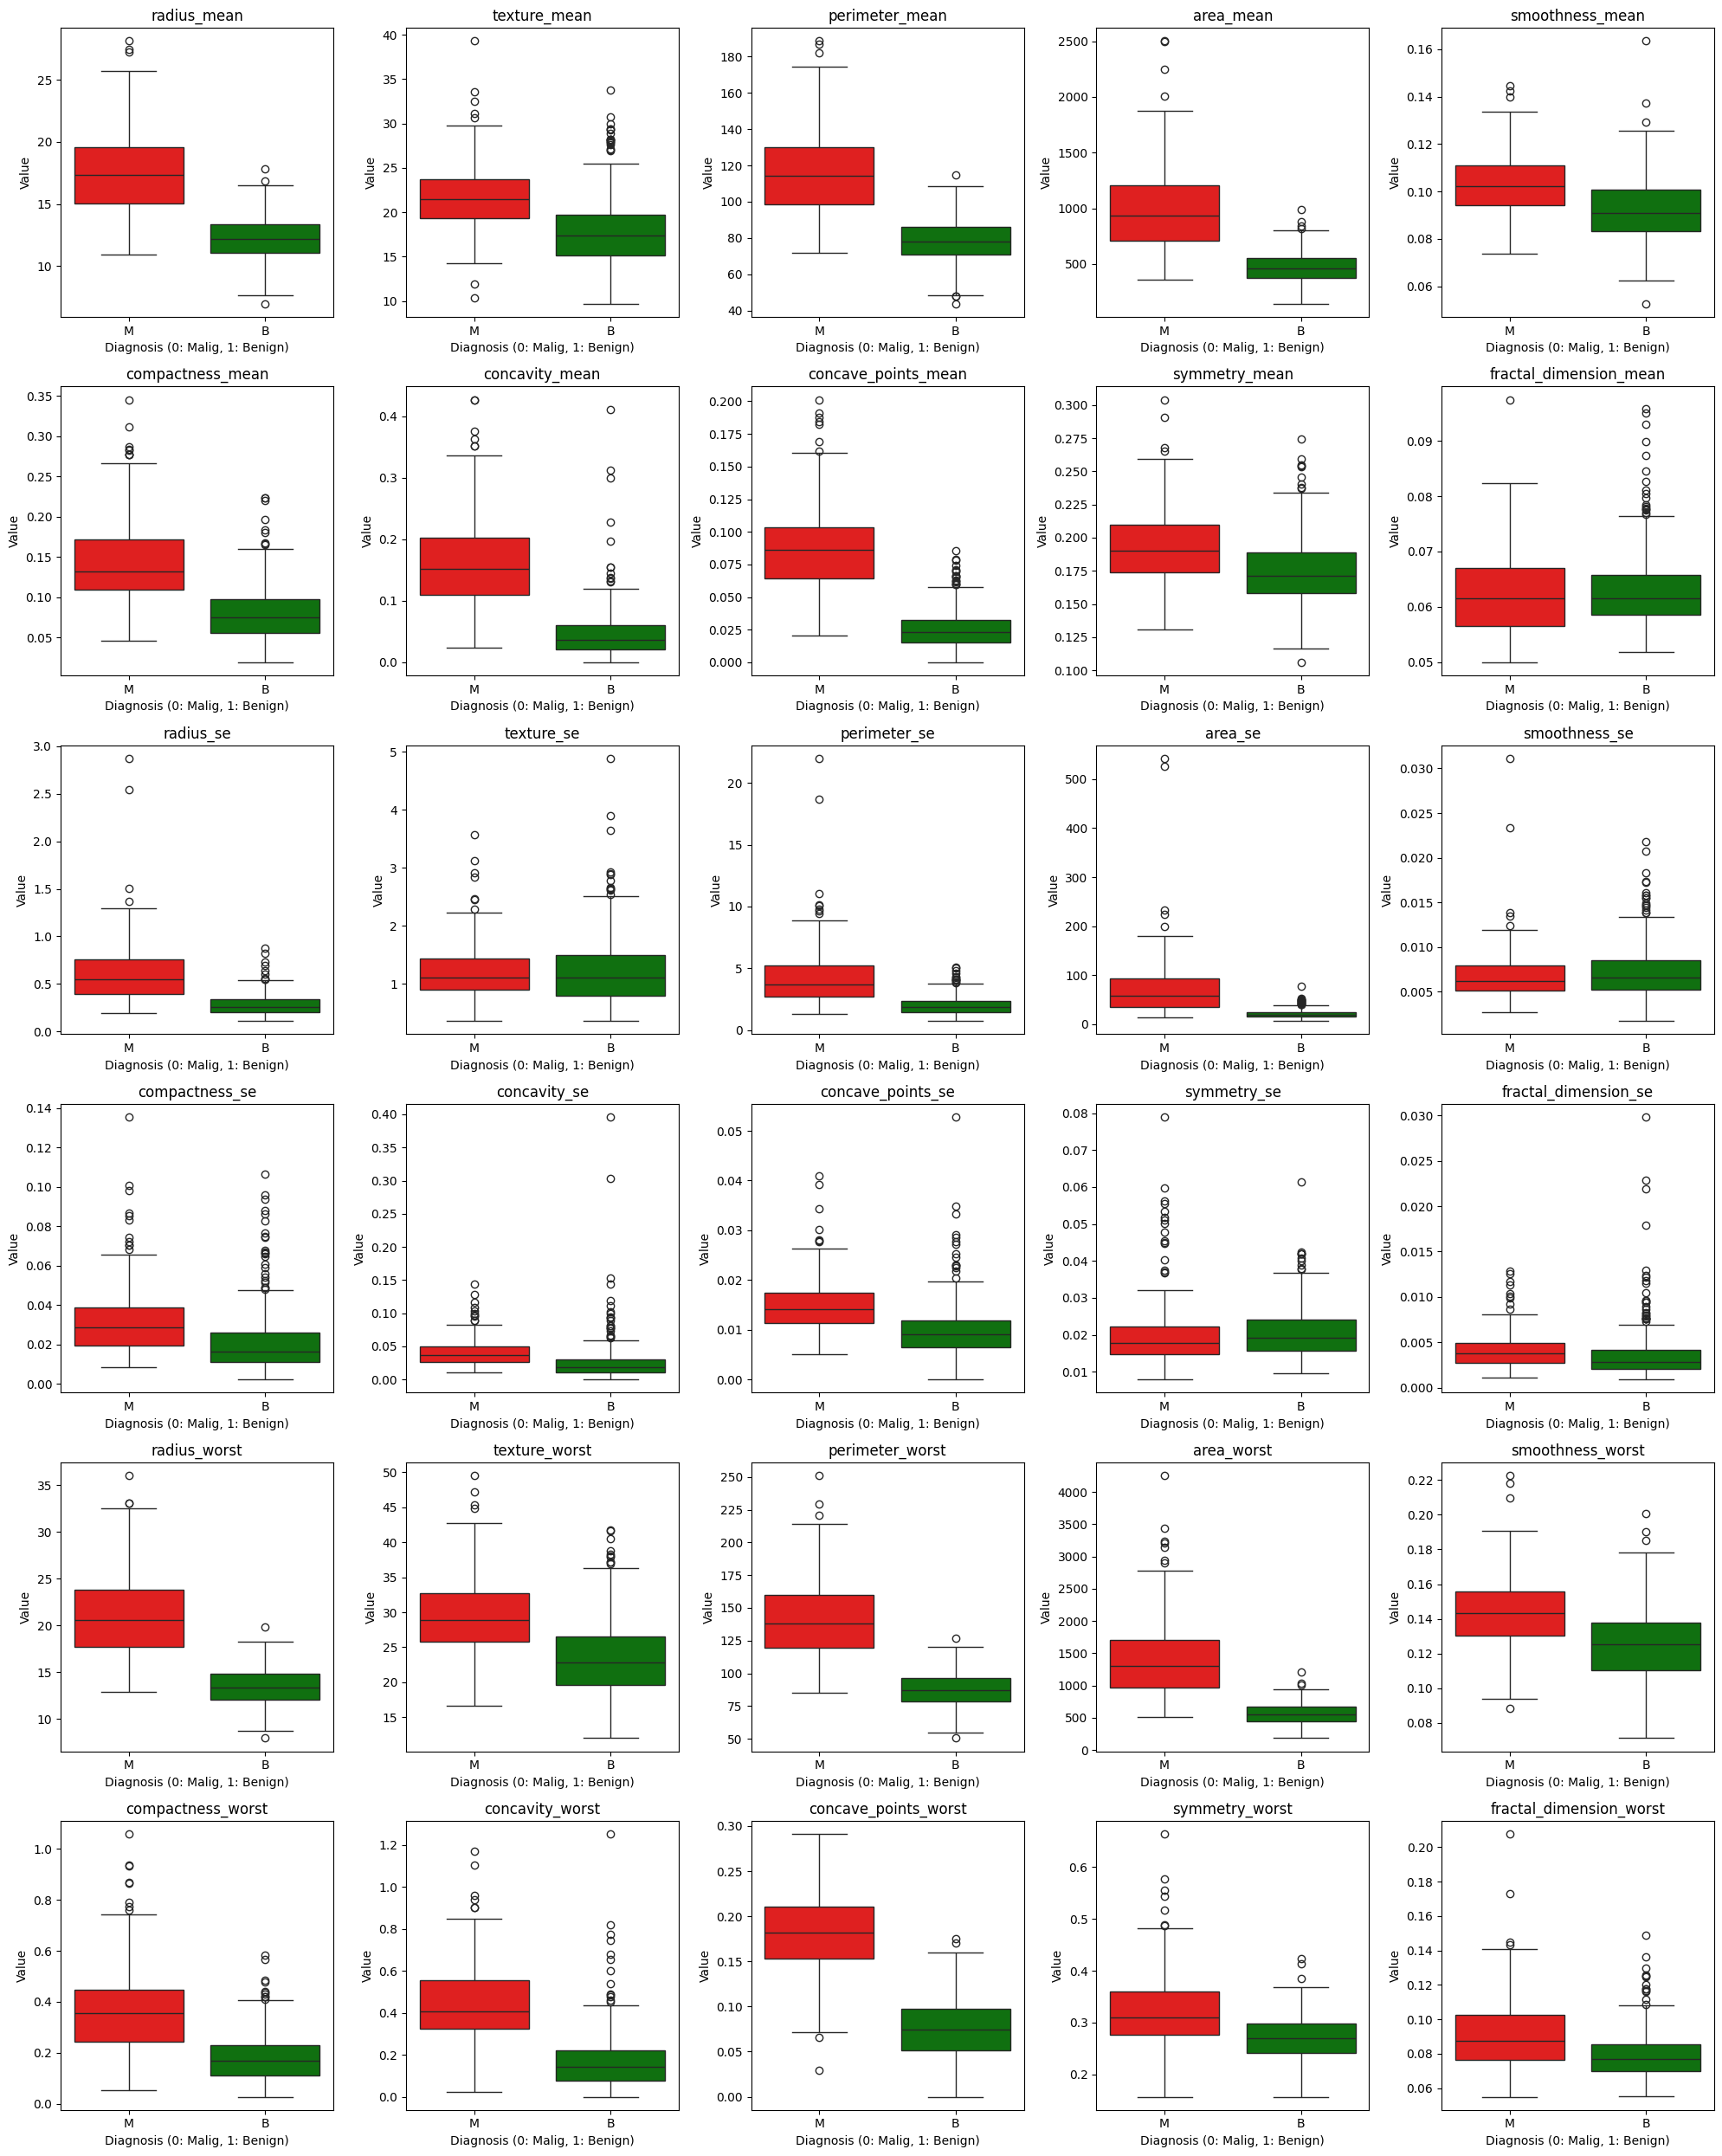

In [25]:
import warnings
warnings.filterwarnings('ignore')

fig, axes = plt.subplots(nrows=6, ncols=5, figsize=(20, 25))
axes = axes.flatten()

features = [col for col in df.columns if col != 'target']
for i, col in enumerate(features):
    sns.boxplot(x='target', y=col, data=df, ax=axes[i], palette={'M':'red','B':'green'})
    axes[i].set_title(col)
    axes[i].set_xlabel('Diagnosis (0: Malig, 1: Benign)')
    axes[i].set_ylabel('Value')

plt.tight_layout()
plt.show()

Visualization Analysis:
Many features like radius_worst, perimeter_worst, and concave_points_worst show a very clear separation between Benign and Malignant cases. Malignant tumors generally show higher mean values across size and concavity metrics. This suggests a linear model might actually perform quite well here.

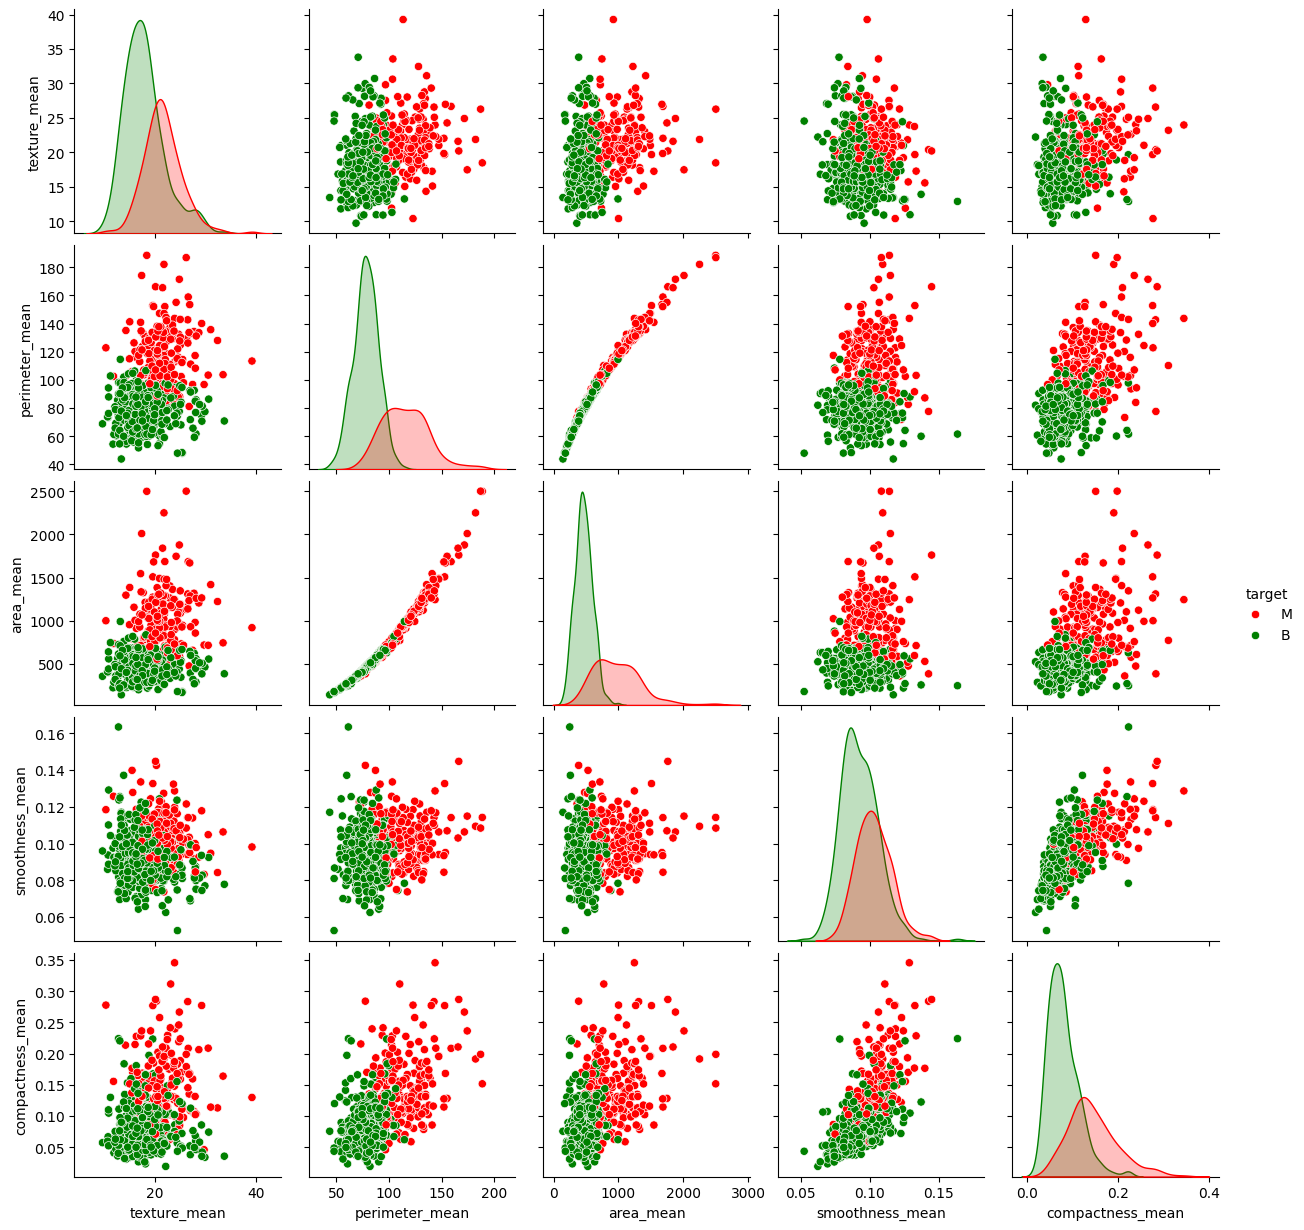

In [17]:

sns.pairplot(df.iloc[:, 1:6].join(df["target"]), hue="target", palette={"M":"red","B":"green"})


### Feature Selection:

Too much feature, we need to perform selection. 
Instead of using all 30 features (which might lead to overfitting on such a small dataset), We're focusing on the top 5 features. These are chosen based on their correlation with the diagnosis and their visual separation in the boxplots.

### Preprocessing:

In order to retain the most relevant feature to predict the target (Benign or Malign), we will perform a simple logistic regression with L1 regularization.

But first, let's standardize the datas

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

df_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [19]:
df_scaled

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,2.110995,0.721473,2.060786,2.343856,1.041842,0.219060,1.947285,2.320965,-0.312589,-0.931027,...,1.901185,0.117700,1.752563,2.015301,0.378365,-0.273318,0.664512,1.629151,-1.360158,-0.709091
565,1.704854,2.085134,1.615931,1.723842,0.102458,-0.017833,0.693043,1.263669,-0.217664,-1.058611,...,1.536720,2.047399,1.421940,1.494959,-0.691230,-0.394820,0.236573,0.733827,-0.531855,-0.973978
566,0.702284,2.045574,0.672676,0.577953,-0.840484,-0.038680,0.046588,0.105777,-0.809117,-0.895587,...,0.561361,1.374854,0.579001,0.427906,-0.809587,0.350735,0.326767,0.414069,-1.104549,-0.318409
567,1.838341,2.336457,1.982524,1.735218,1.525767,3.272144,3.296944,2.658866,2.137194,1.043695,...,1.961239,2.237926,2.303601,1.653171,1.430427,3.904848,3.197605,2.289985,1.919083,2.219635


In [20]:
y_binary = y.replace({'B': 0, 'M': 1})

In [21]:
y_binary = y_binary.astype(int).values.ravel()

In [26]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(penalty='l1', solver='liblinear', C=0.05)
model.fit(X, y_binary)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.05
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass

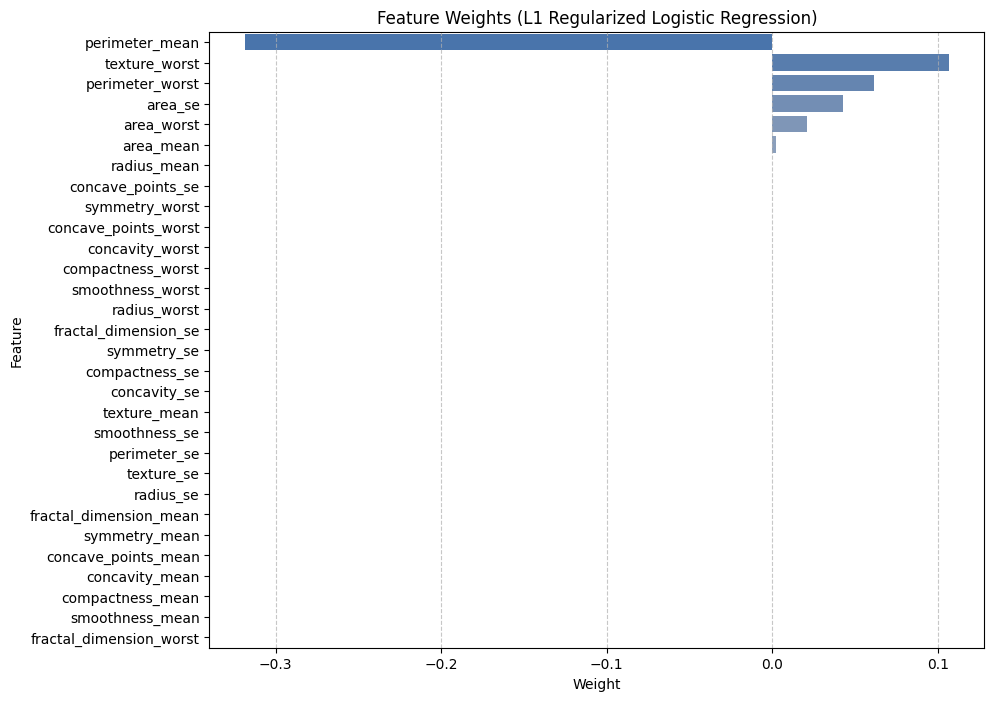

In [27]:

weights_df = pd.DataFrame({
    'Feature': X.columns,
    'Weight': model.coef_[0]
})

weights_df['AbsWeight'] = weights_df['Weight'].abs()
weights_df = weights_df.sort_values(by='AbsWeight', ascending=False)

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.barplot(x='Weight', y='Feature', data=weights_df, palette='vlag')
plt.title('Feature Weights (L1 Regularized Logistic Regression)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [28]:
k = 5 # we select 5 parameters
weights_df['Feature'].iloc[:k].tolist()

['perimeter_mean', 'texture_worst', 'perimeter_worst', 'area_se', 'area_worst']

In [29]:
important_features = weights_df['Feature'].iloc[:k].tolist()

### Model Training

In [30]:
from sklearn.model_selection import cross_validate, KFold, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X_selected = X[important_features]
y_clean = y_binary

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(penalty=None, class_weight='balanced')) #use class_weight balanced in order to reweight the 1/3 vs 2/3 class
])

# Setup K-Fold
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) #Stratify in order to avoid the unbalance between class to biased

# Run Cross-Validation for multiple metrics
scoring = ['accuracy', 'recall', 'precision', 'f1']
results = cross_validate(pipeline, X_selected, y_binary, cv=kf, scoring=scoring)

# Display results
print(f"Average Accuracy: {results['test_accuracy'].mean():.2%}")
print(f"Average Recall:   {results['test_recall'].mean():.2%}")
print(f"Average F1-Score: {results['test_f1'].mean():.2%}")

Average Accuracy: 94.38%
Average Recall:   93.42%
Average F1-Score: 92.47%


same as before, but using a lower threshold  (0.2 instead of 0.5) in order to get a higher recall, in order to miss the fewer Malign cancers.

In [31]:
from sklearn.model_selection import KFold
from sklearn.metrics import recall_score, accuracy_score, precision_score
import numpy as np


threshold = 0.2
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=4)

recalls, accuracies, precisions = [], [], []

for train_index, test_index in kf.split(X_selected, y_clean):

    X_train, X_test = X_selected.iloc[train_index], X_selected.iloc[test_index]
    y_train, y_test = y_clean[train_index], y_clean[test_index]
    
    pipeline.fit(X_train, y_train)
    
    y_probs = pipeline.predict_proba(X_test)[:, 1]
    
    y_pred_custom = (y_probs >= threshold).astype(int)
    
    recalls.append(recall_score(y_test, y_pred_custom))
    accuracies.append(accuracy_score(y_test, y_pred_custom))
    precisions.append(precision_score(y_test, y_pred_custom))

print(f"--- Results with Threshold {threshold} ---")
print(f"Mean Accuracy:  {np.mean(accuracies):.2%}")
print(f"Mean Recall:    {np.mean(recalls):.2%}")
print(f"Mean Precision: {np.mean(precisions):.2%}")

--- Results with Threshold 0.2 ---
Mean Accuracy:  92.80%
Mean Recall:    98.13%
Mean Precision: 85.07%


### XAI part

In [32]:
features = X_selected.columns 

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        penalty=None,
        class_weight='balanced',  # Handles the 1/3 vs 2/3 target imbalance
        random_state=42
    ))
])


final_pipeline.fit(X_selected, y_clean)

# 3. Extract the trained model and weights for your XAI plot
final_model = final_pipeline.named_steps['clf']
weights = final_model.coef_[0]

# 3. Calculate Odds Ratios
odds_ratios = np.exp(weights)

# 4. Create the DataFrame safely
df_xai = pd.DataFrame({
    'Feature': features,
    'Weight': weights,
    'Odds_Ratio': odds_ratios
})

# Filter out features that were zeroed out (just in case)
df_xai = df_xai[df_xai['Weight'] != 0].copy()

# Sort by the absolute weight for impact
df_xai['Abs_Weight'] = df_xai['Weight'].abs()
df_xai = df_xai.sort_values(by='Abs_Weight', ascending=False).head(10) # Top 10

# Now you can run the plotting code!

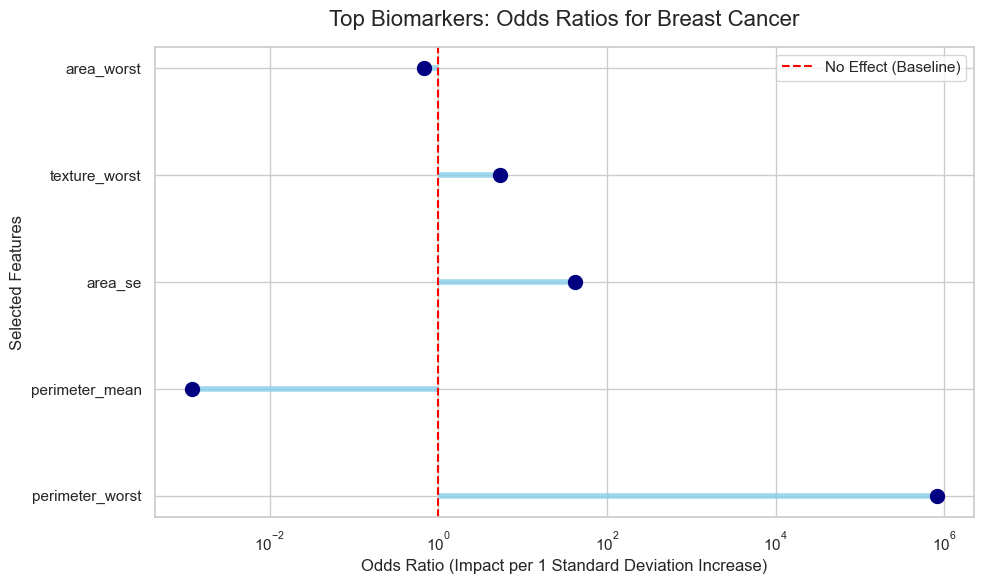

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

plt.xscale('log') 

plt.xlabel('Odds Ratio (Log Scale)', fontsize=12)

plt.hlines(y=df_xai['Feature'], 
           xmin=1, 
           xmax=df_xai['Odds_Ratio'], 
           color='skyblue', 
           alpha=0.8, 
           linewidth=4)

plt.plot(df_xai['Odds_Ratio'], 
         df_xai['Feature'], 
         "o", 
         markersize=10, 
         color='navy')


plt.axvline(x=1.0, color='red', linestyle='--', label='No Effect (Baseline)')

plt.title('Top Biomarkers: Odds Ratios for Breast Cancer', fontsize=16, pad=15)
plt.xlabel('Odds Ratio (Impact per 1 Standard Deviation Increase)', fontsize=12)
plt.ylabel('Selected Features', fontsize=12)

plt.legend()
plt.tight_layout()
plt.show()

### Random forest Approach

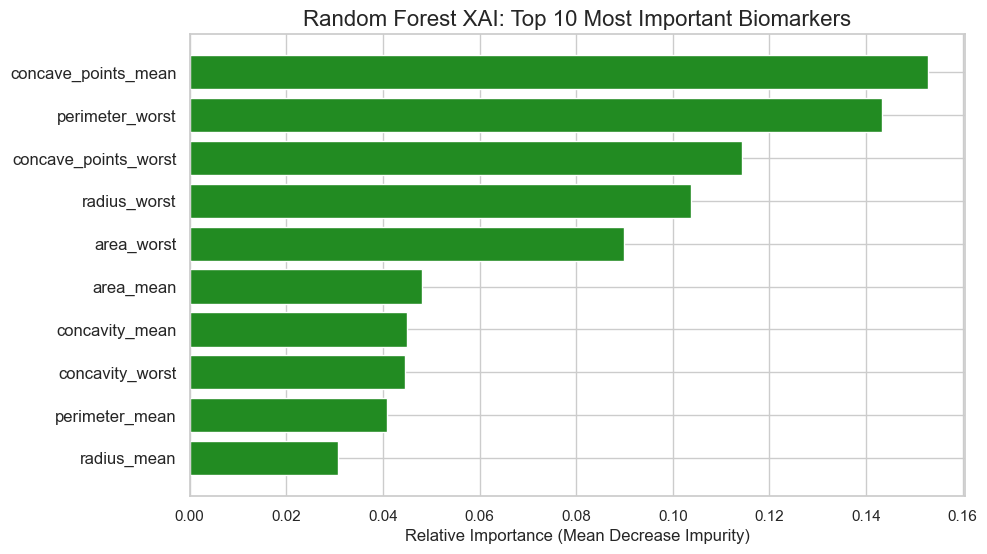

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate
import matplotlib.pyplot as plt
import numpy as np

# Random Forest Pipeline (No StandardScaler needed for RF, but good practice if mixed with other models)
rf_model = RandomForestClassifier(
    n_estimators=100, 
    class_weight='balanced', # Handles your 63/37 split
    random_state=44
)

# Train the model
rf_model.fit(X, y)

# XAI: Feature Importance Analysis
# Extract feature importances from the trained forest
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1] # Sort descending

# Get top 10 features for the plot
top_n = 10
top_indices = indices[:top_n]
top_features = X.columns[top_indices]
top_importances = importances[top_indices]

# Plotting the XAI (Feature Selection/Importance)
plt.figure(figsize=(10, 6))
plt.barh(range(top_n), top_importances[::-1], color='forestgreen', align='center')
plt.yticks(range(top_n), top_features[::-1], fontsize=12)
plt.xlabel('Relative Importance (Mean Decrease Impurity)', fontsize=12)
plt.title('Random Forest XAI: Top 10 Most Important Biomarkers', fontsize=16)
plt.show()

Let's take top 5 (scew method)

In [35]:
# Get top k features for the plot (k = 5)
top_k = 5
top_indices = indices[:top_k]
top_features = X.columns[top_indices]
top_importances = importances[top_indices]

In [36]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, recall_score, precision_score, accuracy_score

# Filter X to only include the Top 5 features we found earlier
X_top = X[top_features]

# Define the new, leaner Random Forest
rf_top = RandomForestClassifier(
    n_estimators=100, 
    class_weight='balanced', 
    random_state=42
)

# Define the Stratified K-Fold (Fixing the previous error by passing 'y' later!)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Note: Since your target 'y' is 'B' and 'M', we need to tell the scorers that 'M' is the positive class we care about finding.
scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, pos_label='M'),
    'recall': make_scorer(recall_score, pos_label='M')
}

# Run Cross-Validation
cv_results = cross_validate(rf_top, X_top, y, cv=skf, scoring=scoring)

# Print the unbiased metrics
print("--- 5-Feature Random Forest Performance ---")
print(f"Mean Accuracy:  {cv_results['test_accuracy'].mean():.4f} (+/- {cv_results['test_accuracy'].std():.4f})")
print(f"Mean Precision: {cv_results['test_precision'].mean():.4f} (+/- {cv_results['test_precision'].std():.4f})")
print(f"Mean Recall:    {cv_results['test_recall'].mean():.4f} (+/- {cv_results['test_recall'].std():.4f})")

--- 5-Feature Random Forest Performance ---
Mean Accuracy:  0.9350 (+/- 0.0225)
Mean Precision: 0.9147 (+/- 0.0451)
Mean Recall:    0.9154 (+/- 0.0683)


##### XAI analysis

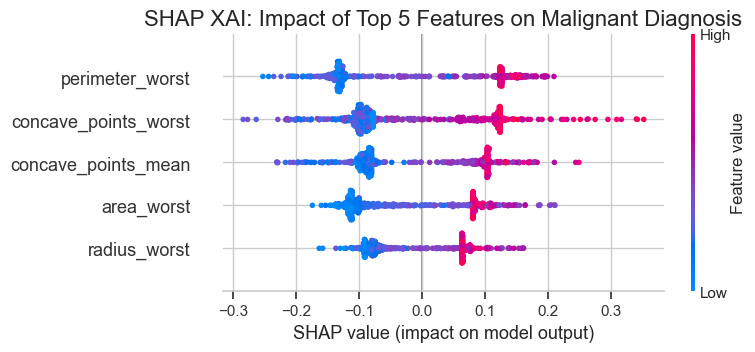

In [40]:
import shap

rf_top.fit(X_top, y)

# Initialize the SHAP TreeExplainer (specifically built for Random Forests)
explainer = shap.TreeExplainer(rf_top)

shap_values = explainer.shap_values(X_top)

shap_values_malignant = shap_values[:, :, 1] if len(np.array(shap_values).shape) == 3 else shap_values[1]

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_malignant, X_top, show=False)
plt.title("SHAP XAI: Impact of Top 5 Features on Malignant Diagnosis", fontsize=16)
plt.show()

## Final Project Conclusion

Results Analysis:
The model shows high performance using just the Top 5 features identified during EDA. However, in a clinical breast cancer diagnostic tool, Accuracy is a misleading metric. >
If we have a 95% accuracy but a low Recall, we are effectively telling cancer patients they are healthy (False Negatives). In medical contexts, a False Negative is significantly more dangerous than a False Positive (which just results in a follow-up biopsy).

XAI Interpretation (SHAP):
The SHAP beeswarm plot shows that concave_points_worst and area_worst are the most influential predictors.

High values for these features (shown in red) have a positive SHAP value, meaning they strongly push the model to predict Malignant.

This makes sense biologically, as larger, more concave (irregularly shaped) cell nuclei are classic indicators of malignancy.

Future Improvements:
To make this model safer for university or hospital use, we should tune the classification threshold. Instead of the default 0.5, lowering it to 0.3 would increase our Recall for the Malignant class, ensuring fewer cases are missed, even at the cost of a few more benign "false alarms."